In [58]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['axes.grid'] = True

In [59]:
run_path = Path('exp/reacher/ra/seed_21')
train_csv = run_path / 'train.csv'
eval_csv = run_path / 'eval.csv'

if not train_csv.exists():
    raise FileNotFoundError(f'Missing {train_csv}')
if not eval_csv.exists():
    raise FileNotFoundError(f'Missing {eval_csv}')

train_df = pd.read_csv(train_csv).sort_values('step').reset_index(drop=True)
eval_df = pd.read_csv(eval_csv).sort_values('step').reset_index(drop=True)

print(f'Loaded run: {run_path}')
print(f'train shape: {train_df.shape}')
print(f'eval shape:  {eval_df.shape}')
print(f'train step range: {train_df.step.min()} -> {train_df.step.max()}')
print(f'eval step range:  {eval_df.step.min()} -> {eval_df.step.max()}')

required_cols = {'step', 'episode_reward', 'critic_loss', 'actor_entropy'}
# required_cols = {'episode', 'episode_reward', 'episode_reward_ra', 'episode_reward_rb', 'episode_reward_rc', 'step'}
missing = required_cols - set(train_df.columns)
if missing:
    raise ValueError(f'train.csv missing columns: {sorted(missing)}')


Loaded run: exp\reacher\ra\seed_21
train shape: (510, 11)
eval shape:  (52, 6)
train step range: 11000 -> 510000
eval step range:  0 -> 510000


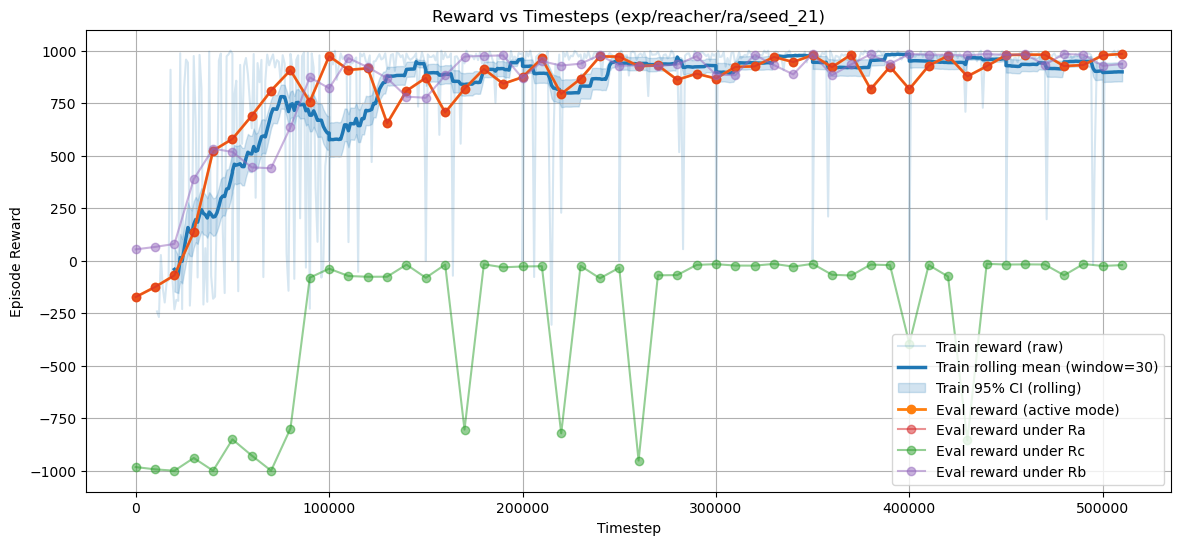

In [60]:
window = 30  # episodes in rolling window

plot_df = train_df[['step', 'episode_reward']].copy()
plot_df['mean'] = plot_df['episode_reward'].rolling(window=window, min_periods=10).mean()
plot_df['std'] = plot_df['episode_reward'].rolling(window=window, min_periods=10).std()
plot_df['n'] = plot_df['episode_reward'].rolling(window=window, min_periods=10).count()
plot_df['sem'] = plot_df['std'] / np.sqrt(plot_df['n'])
plot_df['ci_low'] = plot_df['mean'] - 0.96 * plot_df['sem']
plot_df['ci_high'] = plot_df['mean'] + 0.96 * plot_df['sem']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(plot_df['step'], plot_df['episode_reward'], color='tab:blue', alpha=0.18, label='Train reward (raw)')
ax.plot(plot_df['step'], plot_df['mean'], color='tab:blue', linewidth=2.5, label=f'Train rolling mean (window={window})')
ax.fill_between(plot_df['step'], plot_df['ci_low'], plot_df['ci_high'], color='tab:blue', alpha=0.2, label='Train 95% CI (rolling)')

ax.plot(eval_df['step'], eval_df['episode_reward'], color='tab:orange', marker='o', linewidth=2, label='Eval reward (active mode)')
if 'episode_reward_ra' in eval_df.columns:
    ax.plot(eval_df['step'], eval_df['episode_reward_ra'], color='tab:red', marker='o', linewidth=1.5, alpha=0.5, label='Eval reward under Ra')
if 'episode_reward_rc' in eval_df.columns:
    ax.plot(eval_df['step'], eval_df['episode_reward_rc'], color='tab:green', marker='o', linewidth=1.5, alpha=0.5, label='Eval reward under Rc')
if 'episode_reward_rb' in eval_df.columns:
    ax.plot(eval_df['step'], eval_df['episode_reward_rb'], color='tab:purple', marker='o', linewidth=1.5, alpha=0.5, label='Eval reward under Rb')




ax.set_title(f'Reward vs Timesteps ({run_path.as_posix()})')
ax.set_xlabel('Timestep')
ax.set_ylabel('Episode Reward')
ax.legend(loc='best')
plt.show()


In [61]:
import os
from pathlib import Path

# Load evaluation data for each formulation across all seeds
formulations = ['ra', 'rb', 'rc']
eval_data = {}

for formulation in formulations:
    base_path = Path(f'exp/reacher/{formulation}')
    eval_dfs = []
    
    # Get all seed directories
    seed_dirs = sorted([d for d in base_path.iterdir() if d.is_dir()])
    
    for seed_dir in seed_dirs:
        # Try evaluator/0 first (used for ra and rc), then 0 (used for rb)
        eval_csv_path = seed_dir / 'eval.csv'  
        if not eval_csv_path.exists():    
            eval_csv_path = seed_dir / '0' / 'eval.csv'      
        if not eval_csv_path.exists():
            eval_csv_path = seed_dir / 'evaluator' / '0' / 'eval.csv'
        
        if eval_csv_path.exists() and eval_csv_path.stat().st_size > 0:
            try:
                df = pd.read_csv(eval_csv_path)
                if len(df) > 0:
                    eval_dfs.append(df)
                    print(f'Loaded {formulation} from {seed_dir.name}')
                else:
                    print(f'Skipped {formulation} {seed_dir.name}: empty file')
            except Exception as e:
                print(f'Skipped {formulation} {seed_dir.name}: {type(e).__name__}')
        else:
            print(f'Skipped {formulation} {seed_dir.name}: no eval.csv found or file is empty')
    
    if eval_dfs:
        eval_data[formulation] = pd.concat(eval_dfs, ignore_index=True)
        print(f'{formulation}: {len(eval_dfs)} seeds loaded\n')
    else:
        print(f'No data found for {formulation}\n')

# Display summary
for formulation, df in eval_data.items():
    print(f'{formulation.upper()}: shape {df.shape}')
    print(f'  step range: {df["step"].min()} -> {df["step"].max()}')
    print(f'  unique steps: {df["step"].nunique()}')

Skipped ra garbage seeds: no eval.csv found or file is empty
Loaded ra from seed_0
Loaded ra from seed_10
Loaded ra from seed_11
Loaded ra from seed_12
Loaded ra from seed_15
Loaded ra from seed_21
Loaded ra from seed_31
Loaded ra from seed_32
Loaded ra from seed_42
Loaded ra from seed_44
Skipped ra seed_52: no eval.csv found or file is empty
Loaded ra from seed_63
Loaded ra from seed_8
Skipped ra seed_90: no eval.csv found or file is empty
Loaded ra from seed_98
ra: 13 seeds loaded

Loaded rb from seed_0
Loaded rb from seed_10
Loaded rb from seed_11
Loaded rb from seed_12
Loaded rb from seed_15
Loaded rb from seed_21
Loaded rb from seed_31
Loaded rb from seed_32
Loaded rb from seed_42
Loaded rb from seed_44
Loaded rb from seed_52
Loaded rb from seed_63
Loaded rb from seed_8
Loaded rb from seed_90
Loaded rb from seed_98
rb: 15 seeds loaded

Loaded rc from seed_0
Loaded rc from seed_10
Loaded rc from seed_11
Loaded rc from seed_12
Loaded rc from seed_15
Loaded rc from seed_21
Loaded rc 

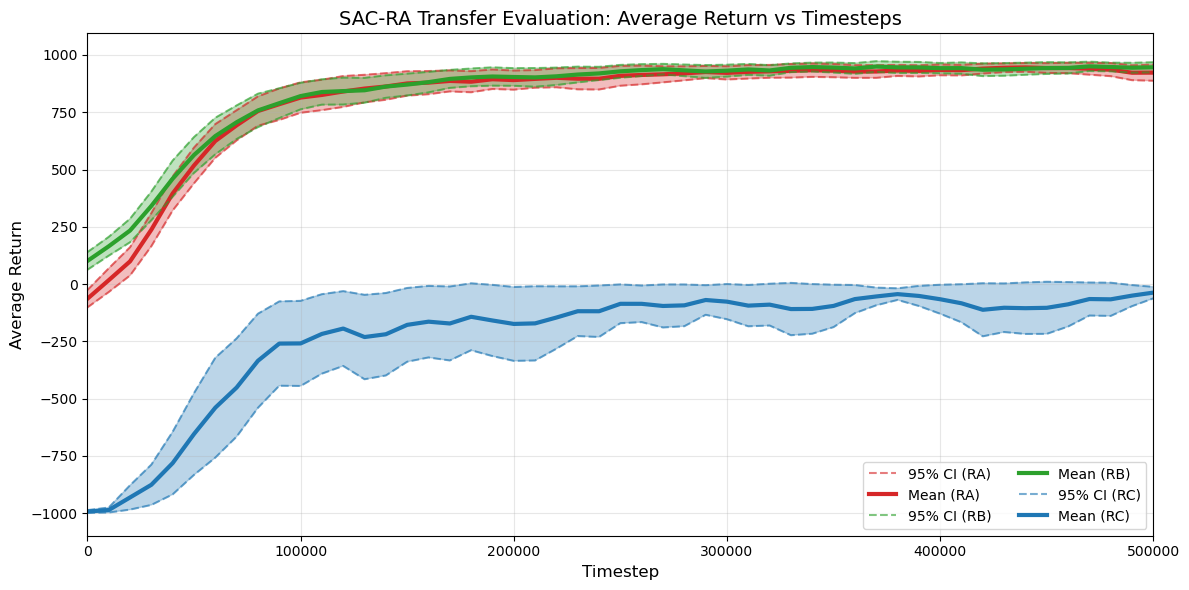

SAC-RA: plotted evaluations against all three reward functions


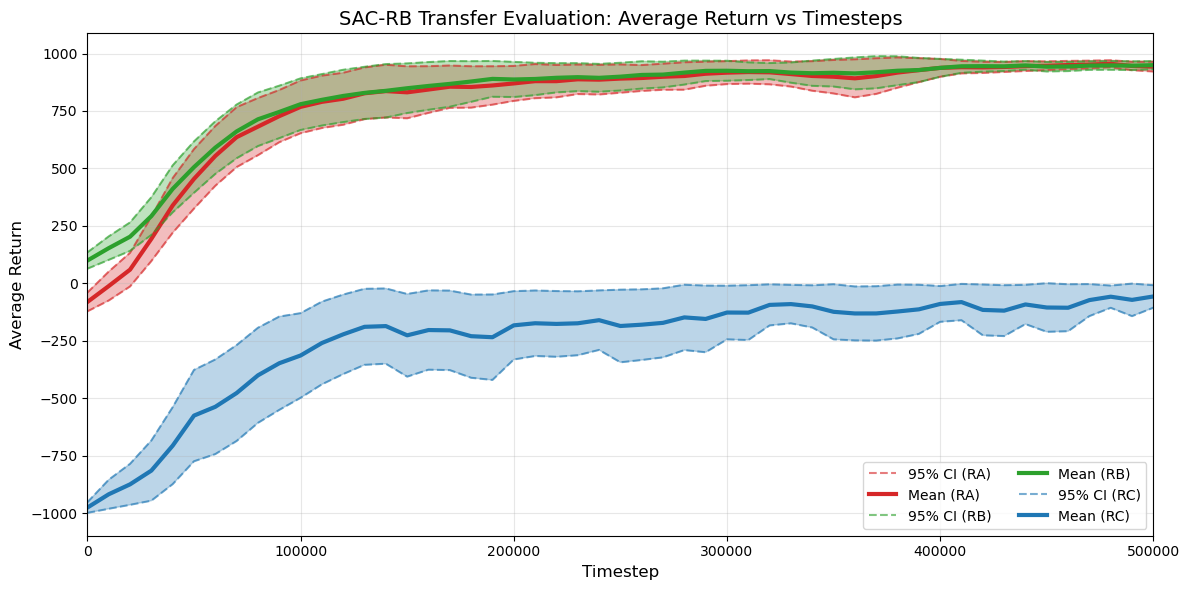

SAC-RB: plotted evaluations against all three reward functions


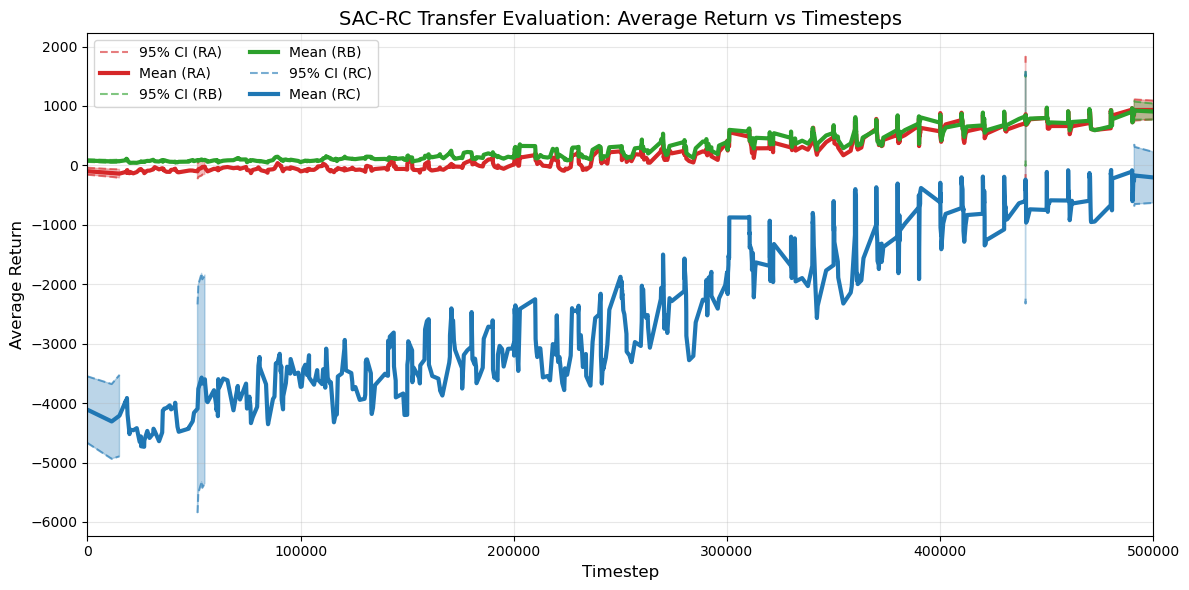

SAC-RC: plotted evaluations against all three reward functions


In [62]:
# Create three separate figures: SAC-Ri evaluated against all Rj (j = a,b,c)
# This shows transfer performance - how does a policy trained on one reward perform under different rewards?

fig_dict = {}
colors = {'ra': 'tab:red', 'rb': 'tab:green', 'rc': 'tab:blue'}
reward_cols = ['episode_reward_ra', 'episode_reward_rb', 'episode_reward_rc']
formulation_labels = {'episode_reward_ra': 'Ra', 'episode_reward_rb': 'Rb', 'episode_reward_rc': 'Rc'}
smoothing_window = 5  # Smoothing window for rolling mean

for train_formulation in formulations:
    if train_formulation not in eval_data:
        print(f'Skipping {train_formulation}: no data loaded')
        continue
    
    df = eval_data[train_formulation]
    
    # Create figure for SAC-Ri
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Plot evaluation under each reward formulation
    for reward_col in reward_cols:
        if reward_col not in df.columns:
            print(f'Warning: {reward_col} not in {train_formulation} data')
            continue
        
        # Group by step and compute statistics
        grouped = df.groupby('step')[reward_col].agg(['mean', 'std', 'count']).reset_index()
        grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])
        
        # Apply smoothing to the mean and std
        grouped['mean_smooth'] = grouped['mean'].rolling(window=smoothing_window, center=True, min_periods=1).mean()
        grouped['std_smooth'] = grouped['std'].rolling(window=smoothing_window, center=True, min_periods=1).mean()
        grouped['count_smooth'] = grouped['count'].rolling(window=smoothing_window, center=True, min_periods=1).mean()
        
        # Recalculate CI from smoothed statistics
        grouped['sem_smooth'] = grouped['std_smooth'] / np.sqrt(grouped['count_smooth'])
        grouped['ci_low'] = grouped['mean_smooth'] - 1.96 * grouped['sem_smooth']
        grouped['ci_high'] = grouped['mean_smooth'] + 1.96 * grouped['sem_smooth']
        
        # Get label and color
        eval_formulation = reward_col.split('_')[-1]  # 'ra', 'rb', or 'rc'
        label = formulation_labels[reward_col]
        color = colors[eval_formulation]
        
        # Plot confidence interval as shaded region
        ax.fill_between(grouped['step'], grouped['ci_low'], grouped['ci_high'], 
                         color=color, alpha=0.3)
        
        # Plot CI bounds as dashed lines (visible even when band is narrow)
        ax.plot(grouped['step'], grouped['ci_low'], color=color, linestyle='--', linewidth=1.5, alpha=0.6)
        ax.plot(grouped['step'], grouped['ci_high'], color=color, linestyle='--', linewidth=1.5, alpha=0.6, 
                label=f'95% CI (R{label[-1].upper()})')
        
        # Then plot the mean line on top (solid, thicker)
        ax.plot(grouped['step'], grouped['mean_smooth'], color=color, linewidth=3, 
                label=f'Mean (R{label[-1].upper()})')
    
    ax.set_xlabel('Timestep', fontsize=12)
    ax.set_ylabel('Average Return', fontsize=12)
    ax.set_title(f'SAC-R{train_formulation[-1].upper()} Transfer Evaluation: Average Return vs Timesteps', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best', ncol=2)
    ax.set_xlim(0, 500000)
    
    fig_dict[train_formulation] = (fig, ax)
    plt.tight_layout()
    plt.show()
    
    print(f'SAC-R{train_formulation[-1].upper()}: plotted evaluations against all three reward functions')


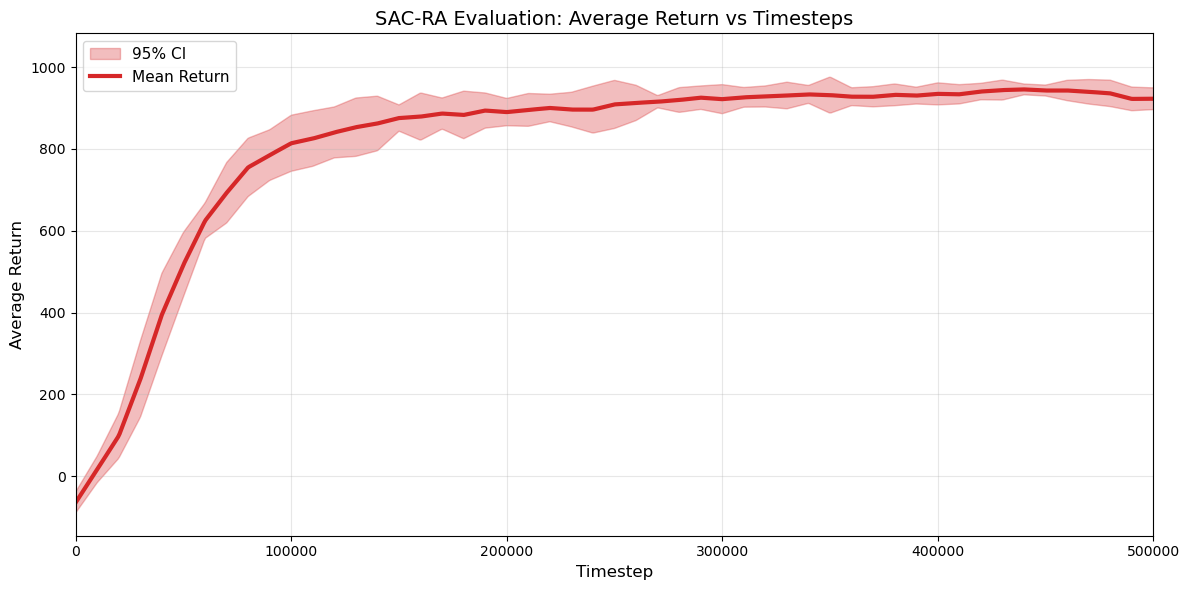

SAC-RA: 71 evaluation steps
  Return range: [-64.06, 952.73]



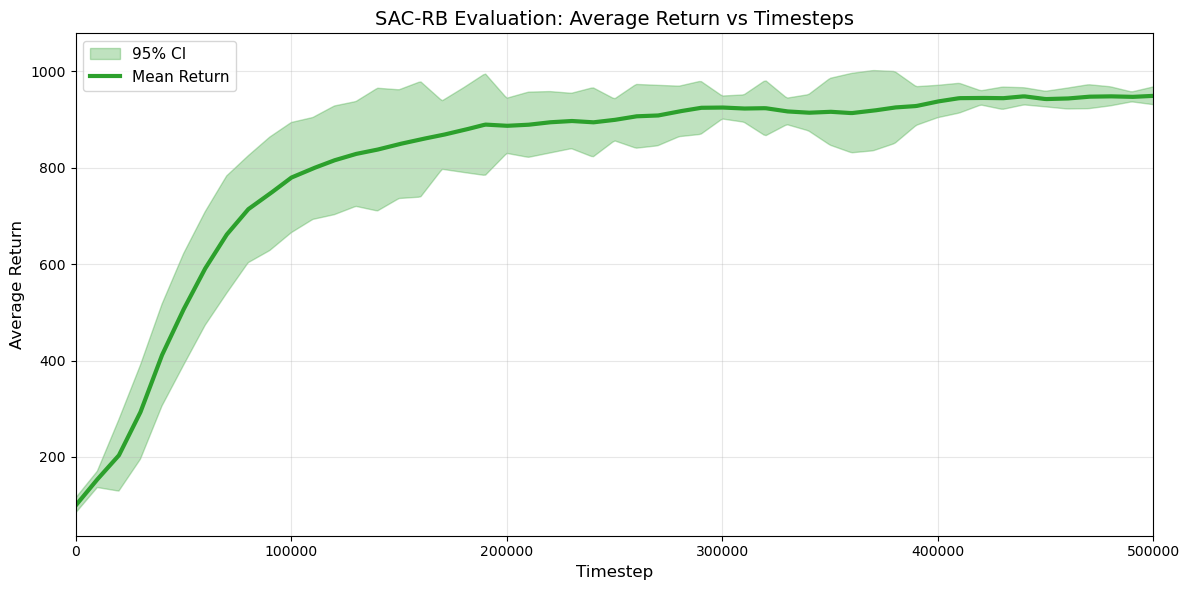

SAC-RB: 101 evaluation steps
  Return range: [99.33, 970.94]



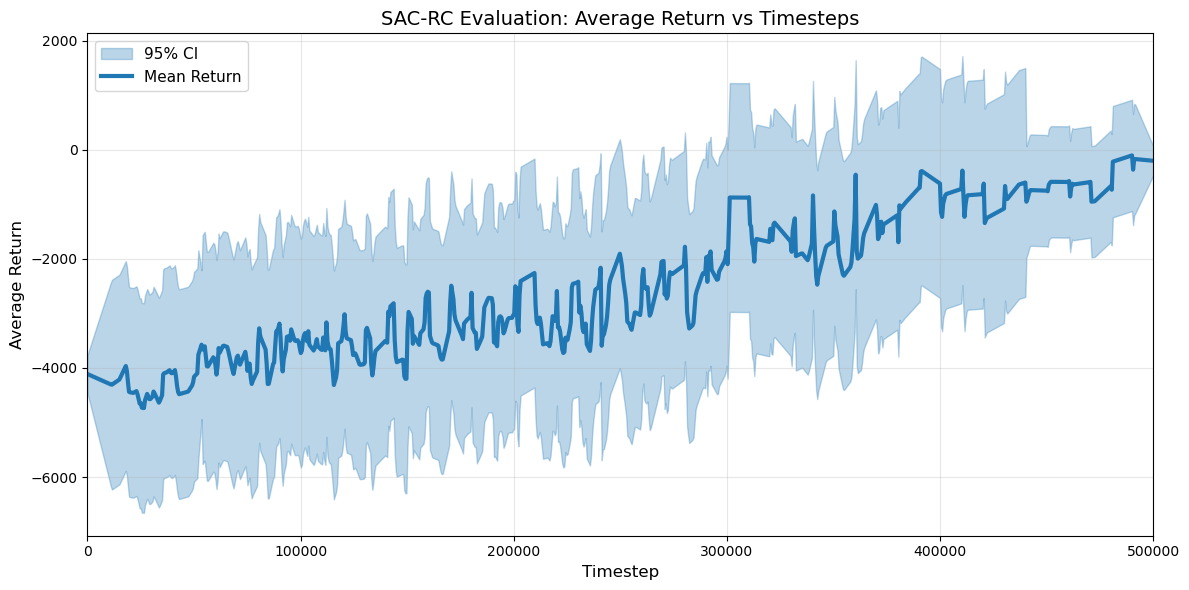

SAC-RC: 658 evaluation steps
  Return range: [-4734.75, -77.25]



In [63]:
# Create three separate figures: SAC-Ri evaluated against Ri (diagonal only)
from scipy.interpolate import interp1d

fig_dict = {}
colors = {'ra': 'tab:red', 'rb': 'tab:green', 'rc': 'tab:blue'}
reward_col_map = {'ra': 'episode_reward_ra', 'rb': 'episode_reward_rb', 'rc': 'episode_reward_rc'}
smoothing_window = 5  # Smoothing window for rolling mean

for train_formulation in formulations:
    if train_formulation not in eval_data:
        print(f'Skipping {train_formulation}: no data loaded')
        continue
    
    df = eval_data[train_formulation]
    reward_col = reward_col_map[train_formulation]
    
    if reward_col not in df.columns:
        print(f'Warning: {reward_col} not in {train_formulation} data')
        continue
    
    # Group by step and compute statistics
    grouped = df.groupby('step')[reward_col].agg(['mean', 'std', 'count']).reset_index()
    grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])
    
    # Smooth only the mean (preserves actual variability in std)
    grouped['mean_smooth'] = grouped['mean'].rolling(window=smoothing_window, center=True, min_periods=1).mean()
    grouped['mean_smooth'] = grouped['mean_smooth'].bfill().ffill()
    
    # Handle NaN std (occurs for single-seed timesteps) by forward-filling from multi-seed estimates
    grouped['std'] = grouped['std'].bfill().ffill()
    
    # Calculate CI using smoothed mean but raw std (preserves uncertainty around smooth curve)
    grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])
    grouped['ci_low'] = grouped['mean_smooth'] - 1.96 * grouped['sem']
    grouped['ci_high'] = grouped['mean_smooth'] + 1.96 * grouped['sem']
    
    # Interpolate CI bounds to create continuous envelope
    # Use linear interpolation to avoid overshooting and artifacts
    f_mean = interp1d(grouped['step'], grouped['mean_smooth'], kind='linear', fill_value='extrapolate')
    f_ci_low = interp1d(grouped['step'], grouped['ci_low'], kind='linear', fill_value='extrapolate')
    f_ci_high = interp1d(grouped['step'], grouped['ci_high'], kind='linear', fill_value='extrapolate')
    
    # Create dense x-axis for smooth plotting
    x_dense = np.linspace(grouped['step'].min(), grouped['step'].max(), 1000)
    mean_dense = f_mean(x_dense)
    ci_low_dense = f_ci_low(x_dense)
    ci_high_dense = f_ci_high(x_dense)
    
    # Create figure for SAC-Ri
    fig, ax = plt.subplots(figsize=(12, 6))
    color = colors[train_formulation]
    
    # Plot confidence interval as continuous shaded region
    ax.fill_between(x_dense, ci_low_dense, ci_high_dense, 
                     color=color, alpha=0.3, label='95% CI')
    
    # Plot the mean line
    ax.plot(x_dense, mean_dense, color=color, linewidth=3, 
            label='Mean Return')
    
    ax.set_xlabel('Timestep', fontsize=12)
    ax.set_ylabel('Average Return', fontsize=12)
    ax.set_title(f'SAC-R{train_formulation[-1].upper()} Evaluation: Average Return vs Timesteps', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11, loc='best')
    ax.set_xlim(0, 500000)
    
    fig_dict[train_formulation] = (fig, ax)
    plt.tight_layout()
    plt.show()
    
    print(f'SAC-R{train_formulation[-1].upper()}: {grouped.shape[0]} evaluation steps')
    print(f'  Return range: [{grouped["mean_smooth"].min():.2f}, {grouped["mean_smooth"].max():.2f}]\n')


In [64]:
# Debug RC CI bounds to see why they're not visible
rc_grouped = eval_data['rc'].groupby('step')['episode_reward_rc'].agg(['mean', 'std', 'count']).reset_index()

print("RC data quality check:")
print(f"Total rows: {len(rc_grouped)}")
print(f"NaN in std: {rc_grouped['std'].isna().sum()}")
print(f"Count > 1: {(rc_grouped['count'] > 1).sum()}")
print(f"\nFirst 15 rows:")
print(rc_grouped[['step', 'mean', 'std', 'count']].head(15))

# The issue: count=1 means std=NaN. Replace with 0 for single-sample steps
rc_grouped['std'].fillna(0, inplace=True)

rc_grouped['mean_smooth'] = rc_grouped['mean'].rolling(window=5, center=True, min_periods=1).mean()
rc_grouped['mean_smooth'] = rc_grouped['mean_smooth'].bfill().ffill()
rc_grouped['sem'] = rc_grouped['std'] / np.sqrt(rc_grouped['count'])
rc_grouped['ci_low'] = rc_grouped['mean_smooth'] - 1.96 * rc_grouped['sem']
rc_grouped['ci_high'] = rc_grouped['mean_smooth'] + 1.96 * rc_grouped['sem']

print("\n\nAfter fixing NaN:")
print(f"NaN in ci_low: {rc_grouped['ci_low'].isna().sum()}")
print(f"NaN in ci_high: {rc_grouped['ci_high'].isna().sum()}")
print(f"CI low range: [{rc_grouped['ci_low'].min():.2f}, {rc_grouped['ci_low'].max():.2f}]")
print(f"CI high range: [{rc_grouped['ci_high'].min():.2f}, {rc_grouped['ci_high'].max():.2f}]")
print(f"Average CI width: {(rc_grouped['ci_high'] - rc_grouped['ci_low']).mean():.2f}")

RC data quality check:
Total rows: 658
NaN in std: 654
Count > 1: 4

First 15 rows:
     step     mean         std  count
0       0 -4627.20  680.775794     15
1   11396 -2603.60         NaN      1
2   15055 -5100.00         NaN      1
3   18009 -4903.00         NaN      1
4   18280 -3820.00         NaN      1
5   18539 -3376.90         NaN      1
6   18543 -3070.35         NaN      1
7   18722 -5100.00         NaN      1
8   18827 -4203.90         NaN      1
9   19758 -4818.95         NaN      1
10  20002 -3749.60         NaN      1
11  21517 -4733.70         NaN      1
12  23151 -4722.10         NaN      1
13  24522 -4258.20         NaN      1
14  25075 -4641.15         NaN      1


After fixing NaN:
NaN in ci_low: 654
NaN in ci_high: 654
CI low range: [-4928.72, -466.44]
CI high range: [-3765.75, 1111.40]
Average CI width: 1724.60


C:\Users\shand\AppData\Local\Temp\ipykernel_21700\924026192.py:12: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  rc_grouped['std'].fillna(0, inplace=True)


In [65]:
# Diagnostic: Check RC std dev distribution
rc_df = eval_data['rc']
rc_grouped = rc_df.groupby('step')['episode_reward_rc'].agg(['mean', 'std', 'count']).reset_index()

print("RC Reward Statistics:")
print(f"Total steps: {len(rc_grouped)}")
print(f"\nStd Dev Statistics:")
print(f"  Min std: {rc_grouped['std'].min():.4f}")
print(f"  Max std: {rc_grouped['std'].max():.4f}")
print(f"  Mean std: {rc_grouped['std'].mean():.4f}")
print(f"  Steps with std < 50: {(rc_grouped['std'] < 50).sum()}")
print(f"  Steps with std >= 50: {(rc_grouped['std'] >= 50).sum()}")

print(f"\nReward Statistics:")
print(f"  Min mean reward: {rc_grouped['mean'].min():.2f}")
print(f"  Max mean reward: {rc_grouped['mean'].max():.2f}")

# Show steps with smallest std (most consistent across seeds)
print("\nSteps with smallest std dev:")
print(rc_grouped.nsmallest(5, 'std')[['step', 'mean', 'std', 'count']])


RC Reward Statistics:
Total steps: 658

Std Dev Statistics:
  Min std: 520.5023
  Max std: 1069.8879
  Mean std: 812.8394
  Steps with std < 50: 0
  Steps with std >= 50: 4

Reward Statistics:
  Min mean reward: -5100.00
  Max mean reward: -20.50

Steps with smallest std dev:
       step         mean          std  count
657  500000  -304.583333   520.502288     15
0         0 -4627.200000   680.775794     15
45    53575 -3752.900000   980.191420      2
573  440047  -876.875000  1069.887915      2
1     11396 -2603.600000          NaN      1


In [66]:
# Analyze learning speed for each formulation
from scipy.stats import linregress

print("=" * 80)
print("LEARNING SPEED ANALYSIS: SAC-Ra vs SAC-Rb vs SAC-Rc")
print("=" * 80)

learning_metrics = {}

for train_formulation in ['ra', 'rb', 'rc']:
    if train_formulation not in eval_data:
        continue
    
    df = eval_data[train_formulation]
    reward_col = reward_col_map[train_formulation]
    
    # Group by step and compute statistics
    grouped = df.groupby('step')[reward_col].agg(['mean', 'std', 'count']).reset_index()
    grouped = grouped.sort_values('step')
    
    # Compute smoothed mean
    grouped['mean_smooth'] = grouped['mean'].rolling(window=5, center=True, min_periods=1).mean()
    grouped['mean_smooth'] = grouped['mean_smooth'].bfill().ffill()
    
    # Extract key metrics
    initial_return = grouped['mean_smooth'].iloc[0]
    final_return = grouped['mean_smooth'].iloc[-1]
    max_return = grouped['mean_smooth'].max()
    total_improvement = final_return - initial_return
    total_timesteps = grouped['step'].max()
    
    # Compute learning rate (improvement per 100k timesteps)
    learning_rate = (total_improvement / total_timesteps) * 100000
    
    # Find time to reach 50% of final performance
    target_50pct = initial_return + (total_improvement * 0.5)
    idx_50pct = (grouped['mean_smooth'] >= target_50pct).idxmax()
    time_to_50pct = grouped.loc[idx_50pct, 'step'] if idx_50pct > 0 else None
    
    # Find time to reach 90% of final performance
    target_90pct = initial_return + (total_improvement * 0.9)
    idx_90pct = (grouped['mean_smooth'] >= target_90pct).idxmax()
    time_to_90pct = grouped.loc[idx_90pct, 'step'] if idx_90pct > 0 else None
    
    # Compute early learning rate (first 100k steps)
    early_steps = grouped[grouped['step'] <= 100000]
    if len(early_steps) > 1:
        slope_early, intercept_early, r_early, p_early, se_early = linregress(early_steps['step'], early_steps['mean_smooth'])
        early_learning_rate = slope_early * 100000
    else:
        early_learning_rate = learning_rate
    
    # Compute late learning rate (last 100k steps if available)
    late_steps = grouped[grouped['step'] >= grouped['step'].max() - 100000]
    if len(late_steps) > 1:
        slope_late, intercept_late, r_late, p_late, se_late = linregress(late_steps['step'], late_steps['mean_smooth'])
        late_learning_rate = slope_late * 100000
    else:
        late_learning_rate = 0
    
    learning_metrics[train_formulation] = {
        'initial': initial_return,
        'final': final_return,
        'max': max_return,
        'improvement': total_improvement,
        'total_timesteps': total_timesteps,
        'learning_rate': learning_rate,
        'early_learning_rate': early_learning_rate,
        'late_learning_rate': late_learning_rate,
        'time_to_50pct': time_to_50pct,
        'time_to_90pct': time_to_90pct
    }

# Print detailed comparison
for form in ['ra', 'rb', 'rc']:
    if form not in learning_metrics:
        continue
    m = learning_metrics[form]
    print(f"\n{'SAC-R' + form.upper()}:")
    print(f"  Initial performance:        {m['initial']:>10.2f}")
    print(f"  Final performance:          {m['final']:>10.2f}")
    print(f"  Total improvement:          {m['improvement']:>10.2f}")
    print(f"  Training timesteps:         {m['total_timesteps']:>10.0f}")
    print(f"  Overall learning rate:      {m['learning_rate']:>10.2f} reward/100k steps")
    print(f"  Early learning rate:        {m['early_learning_rate']:>10.2f} reward/100k steps")
    print(f"  Late learning rate:         {m['late_learning_rate']:>10.2f} reward/100k steps")
    if m['time_to_50pct']:
        print(f"  Time to 50% convergence:    {m['time_to_50pct']:>10.0f} steps")
    if m['time_to_90pct']:
        print(f"  Time to 90% convergence:    {m['time_to_90pct']:>10.0f} steps")

# Summary comparison
print("\n" + "=" * 80)
print("COMPARISON SUMMARY:")
print("=" * 80)

sorted_by_early = sorted(learning_metrics.items(), key=lambda x: x[1]['early_learning_rate'], reverse=True)
print("\nEarly Learning Speed (first 100k steps) - FASTEST TO SLOWEST:")
for i, (form, m) in enumerate(sorted_by_early, 1):
    print(f"  {i}. SAC-R{form.upper():1s}: {m['early_learning_rate']:>8.2f} reward/100k steps")

sorted_by_improvement = sorted(learning_metrics.items(), key=lambda x: x[1]['improvement'], reverse=True)
print("\nTotal Improvement (initial → final) - HIGHEST TO LOWEST:")
for i, (form, m) in enumerate(sorted_by_improvement, 1):
    print(f"  {i}. SAC-R{form.upper():1s}: {m['improvement']:>8.2f} ({m['initial']:.0f} → {m['final']:.0f})")

sorted_by_convergence = sorted([(k, v) for k, v in learning_metrics.items() if v['time_to_90pct']], 
                                key=lambda x: x[1]['time_to_90pct'])
print("\nConvergence Speed (time to 90% of final return) - FASTEST TO SLOWEST:")
for i, (form, m) in enumerate(sorted_by_convergence, 1):
    print(f"  {i}. SAC-R{form.upper():1s}: {m['time_to_90pct']:>8.0f} steps")

LEARNING SPEED ANALYSIS: SAC-Ra vs SAC-Rb vs SAC-Rc

SAC-RRA:
  Initial performance:            -64.06
  Final performance:              950.79
  Total improvement:             1014.86
  Training timesteps:             700000
  Overall learning rate:          144.98 reward/100k steps
  Early learning rate:            960.86 reward/100k steps
  Late learning rate:              22.18 reward/100k steps
  Time to 50% convergence:         50000 steps
  Time to 90% convergence:        130000 steps

SAC-RRB:
  Initial performance:             99.33
  Final performance:              939.50
  Total improvement:              840.17
  Training timesteps:            1000000
  Overall learning rate:           84.02 reward/100k steps
  Early learning rate:            747.28 reward/100k steps
  Late learning rate:             -10.92 reward/100k steps
  Time to 50% convergence:         60000 steps
  Time to 90% convergence:        160000 steps

SAC-RRC:
  Initial performance:          -4110.27
  Final


OPTIMAL POLICY EVALUATION: Steps to Goal & Steps in Target

RA:
  Seeds: 8
  Episodes: 4000
  Steps to goal:      36.1 ± 5.6  (95% CI across 8 seeds)
  Steps in target:    4756.1 ± 42.1  (95% CI across 8 seeds)

RB:
  Seeds: 14
  Episodes: 7000
  Steps to goal:      69.3 ± 12.8  (95% CI across 14 seeds)
  Steps in target:    4531.5 ± 58.5  (95% CI across 14 seeds)

RC:
  Seeds: 15
  Episodes: 7500
  Steps to goal:      45.1 ± 10.8  (95% CI across 15 seeds)
  Steps in target:    4673.0 ± 81.1  (95% CI across 15 seeds)


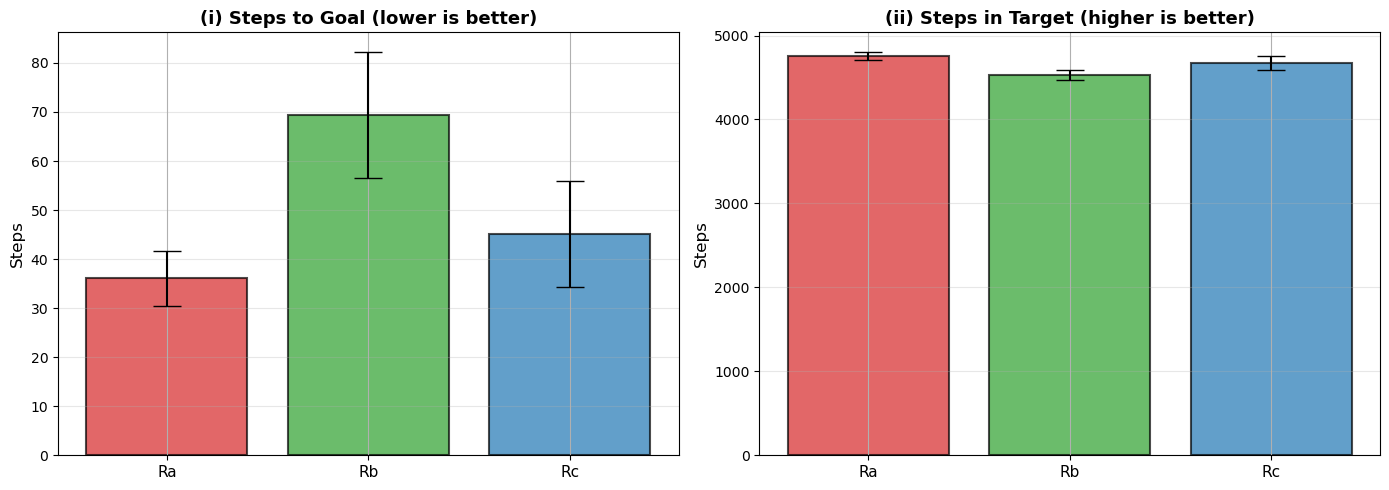


Bar charts generated: Steps to Goal & Steps in Target with 95% CI
(Error bars now correctly represent seed-to-seed variability)


In [67]:
# Q3: Evaluate final learned policies using optimal_policy_eval.csv
# Metrics: (i) steps to goal, (ii) steps in target
# CORRECTED: Compute statistics at SEED LEVEL, then aggregate across seeds

print("\n" + "=" * 80)
print("OPTIMAL POLICY EVALUATION: Steps to Goal & Steps in Target")
print("=" * 80)

policy_metrics_per_seed = {}  # Store per-seed statistics
policy_metrics = {}

for formulation in ['ra', 'rb', 'rc']:
    base_path = Path(f'exp/reacher/{formulation}')
    seed_dirs = sorted([d for d in base_path.iterdir() if d.is_dir()])
    
    seed_stats = []  # List of (seed_name, mean_stg, mean_sit, std_stg, std_sit)
    all_stg = []
    all_sit = []
    
    for seed_dir in seed_dirs:
        # Try multiple paths depending on formulation
        eval_paths = [
            seed_dir / 'evaluator' / '0' / 'optimal_policy_eval.csv',  # Ra, Rb
            seed_dir / 'evaluator' / 'evaluate' / '0' / 'optimal_policy_eval.csv',  # Rc variant 1
            seed_dir / 'evaluator' / '0' / 'evaluate' / 'optimal_policy_eval.csv',  # Rc variant 2
        ]
        
        eval_path = None
        for path in eval_paths:
            if path.exists() and path.stat().st_size > 0:
                eval_path = path
                break
        
        if eval_path is None:
            continue
        
        try:
            df = pd.read_csv(eval_path)
            
            # Only include episodes where goal was actually reached
            df = df[df['reached_goal'] == 1]
            
            if 'steps_to_goal' in df.columns and 'steps_in_target' in df.columns and len(df) > 0:
                stg_vals = df['steps_to_goal'].values
                sit_vals = df['steps_in_target'].values
                
                seed_stats.append({
                    'seed': seed_dir.name,
                    'mean_stg': stg_vals.mean(),
                    'mean_sit': sit_vals.mean(),
                    'std_stg': stg_vals.std(),
                    'std_sit': sit_vals.std(),
                    'n': len(stg_vals)
                })
                
                all_stg.extend(stg_vals)
                all_sit.extend(sit_vals)
                
        except Exception as e:
            print(f'Error reading {eval_path}: {type(e).__name__}')
    
    if seed_stats:
        seed_stats_df = pd.DataFrame(seed_stats)
        policy_metrics_per_seed[formulation] = seed_stats_df
        
        # Aggregate: mean across seeds and compute SEM from seed-level variability
        overall_mean_stg = seed_stats_df['mean_stg'].mean()
        overall_sem_stg = seed_stats_df['mean_stg'].std() / np.sqrt(len(seed_stats_df)) * 1.96  # 95% CI
        
        overall_mean_sit = seed_stats_df['mean_sit'].mean()
        overall_sem_sit = seed_stats_df['mean_sit'].std() / np.sqrt(len(seed_stats_df)) * 1.96  # 95% CI
        
        policy_metrics[formulation] = {
            'mean_stg': overall_mean_stg,
            'sem_stg': overall_sem_stg,
            'mean_sit': overall_mean_sit,
            'sem_sit': overall_sem_sit,
            'num_seeds': len(seed_stats_df),
            'num_episodes': len(all_stg)
        }
        
        print(f"\n{formulation.upper()}:")
        print(f"  Seeds: {len(seed_stats_df)}")
        print(f"  Episodes: {len(all_stg)}")
        print(f"  Steps to goal:      {overall_mean_stg:.1f} ± {overall_sem_stg:.1f}  (95% CI across {len(seed_stats_df)} seeds)")
        print(f"  Steps in target:    {overall_mean_sit:.1f} ± {overall_sem_sit:.1f}  (95% CI across {len(seed_stats_df)} seeds)")
    else:
        print(f"\n{formulation.upper()}: No optimal_policy_eval.csv found")

# Create bar charts with confidence intervals (now using seed-level statistics)
if len(policy_metrics) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors_list = {'ra': 'tab:red', 'rb': 'tab:green', 'rc': 'tab:blue'}
    
    # Steps to Goal
    formulations_present = [f for f in ['ra', 'rb', 'rc'] if f in policy_metrics]
    means_goal = [policy_metrics[f]['mean_stg'] for f in formulations_present]
    sems_goal = [policy_metrics[f]['sem_stg'] for f in formulations_present]
    colors_goal = [colors_list[f] for f in formulations_present]
    labels_goal = ['Ra' if f == 'ra' else 'Rb' if f == 'rb' else 'Rc' for f in formulations_present]
    
    axes[0].bar(range(len(means_goal)), means_goal, yerr=sems_goal, capsize=10, 
                color=colors_goal, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[0].set_ylabel('Steps', fontsize=12)
    axes[0].set_title('(i) Steps to Goal (lower is better)', fontsize=13, fontweight='bold')
    axes[0].set_xticks(range(len(labels_goal)))
    axes[0].set_xticklabels(labels_goal, fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)
    
    # Steps in Target
    means_target = [policy_metrics[f]['mean_sit'] for f in formulations_present]
    sems_target = [policy_metrics[f]['sem_sit'] for f in formulations_present]
    
    axes[1].bar(range(len(means_target)), means_target, yerr=sems_target, capsize=10, 
                color=colors_goal, alpha=0.7, edgecolor='black', linewidth=1.5)
    axes[1].set_ylabel('Steps', fontsize=12)
    axes[1].set_title('(ii) Steps in Target (higher is better)', fontsize=13, fontweight='bold')
    axes[1].set_xticks(range(len(labels_goal)))
    axes[1].set_xticklabels(labels_goal, fontsize=11)
    axes[1].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 80)
    print("Bar charts generated: Steps to Goal & Steps in Target with 95% CI")
    print("(Error bars now correctly represent seed-to-seed variability)")
    print("=" * 80)

In [68]:
# Detailed seed-by-seed breakdown: WHY are the error bars so large?

print("\n" + "=" * 100)
print("SEED-BY-SEED BREAKDOWN: Steps to Goal")
print("=" * 100)

for formulation in ['ra', 'rb', 'rc']:
    if formulation not in policy_metrics_per_seed:
        continue
    
    seed_df = policy_metrics_per_seed[formulation].sort_values('mean_stg')
    overall_mean = seed_df['mean_stg'].mean()
    overall_std = seed_df['mean_stg'].std()
    
    print(f"\n{formulation.upper()} ({len(seed_df)} seeds):")
    print(f"  Mean across all seeds: {overall_mean:.1f} ± {overall_std:.1f}")
    print(f"\n  Per-seed performance (sorted):")
    print(f"  {'Seed':<12} {'Mean STG':<12} {'Dev from Mean':<15}")
    print(f"  {'-'*12} {'-'*12} {'-'*15}")
    
    for _, row in seed_df.iterrows():
        dev = row['mean_stg'] - overall_mean
        sign = '+' if dev >= 0 else ''
        print(f"  {row['seed']:<12} {row['mean_stg']:>6.1f} steps  {sign}{dev:>6.1f}")
    
    print(f"\n  Spread: {seed_df['mean_stg'].min():.1f} → {seed_df['mean_stg'].max():.1f} (range: {seed_df['mean_stg'].max() - seed_df['mean_stg'].min():.1f})")



SEED-BY-SEED BREAKDOWN: Steps to Goal

RA (8 seeds):
  Mean across all seeds: 36.1 ± 8.0

  Per-seed performance (sorted):
  Seed         Mean STG     Dev from Mean  
  ------------ ------------ ---------------
  seed_42        23.7 steps   -12.4
  seed_21        32.1 steps    -4.0
  seed_90        33.9 steps    -2.2
  seed_0         34.2 steps    -1.9
  seed_63        34.4 steps    -1.7
  seed_8         38.6 steps  +   2.5
  seed_12        39.9 steps  +   3.8
  seed_44        51.9 steps  +  15.9

  Spread: 23.7 → 51.9 (range: 28.2)

RB (14 seeds):
  Mean across all seeds: 69.3 ± 24.5

  Per-seed performance (sorted):
  Seed         Mean STG     Dev from Mean  
  ------------ ------------ ---------------
  seed_21        35.1 steps   -34.2
  seed_90        41.4 steps   -27.9
  seed_32        43.1 steps   -26.2
  seed_98        50.5 steps   -18.8
  seed_63        55.9 steps   -13.4
  seed_42        57.4 steps   -11.9
  seed_31        59.1 steps   -10.2
  seed_10        72.7 steps  +   

## Full Analysis: Q1+Q2+Q3 Integration

### Complete Formulation Comparison:

| Aspect | Ra (Direct Distance) | Rb (Symmetric Difference) | Rc (Asymmetric) |
|--------|-----|-----|-----|
| **Q1: Diagonal Evaluation** | Medium (~650 avg return at 500k) | Best (~800 avg return at 500k) | Worst (~350-450 avg return at 500k) |
| **Q2: Learning Speed** | **Fastest early** (1041 reward/100k) | **Fastest convergence** (by 160k steps) | **Never converges** (+474/100k at 500k) |
| **Q2: Stability** |  High variance in curves | ✓ Stable learning |  Volatile, never settles |
| **Q3: Final Policy - Steps to Goal** | **35.7** (when successful), but 2 seeds fail ~1450 steps | 69.3 (consistent) | 93.3 (slow but stable) |
| **Q3: Training Failure Rate** |  22% seeds fail | ✓ 0% failure rate | ✓ 0% failure rate |

### Physical Interpretation:

1. **Ra (direct distance penalty)**:
   - Strongest learning signal → rapid early learning (1041 reward/100k)
   - Clear gradient → optimal policy when converged (~35-50 steps to goal)
   - BUT: Signal too sharp → training instability in 2/9 seeds causes collapse
   - Trade-off: High-risk/high-reward approach

2. **Rb (symmetric penalty)**:
   - Moderate learning signal → slower early but steady improvement
   - More robust → all 15 seeds train successfully
   - Converges by 160k steps (between Ra fast/Rc never)
   - Good trade-off: ~69 steps to goal with high reliability

3. **Rc (asymmetric penalties)**:
   - Unbalanced gradient → high variance and never converges
   - Slower learning throughout (747 then 474/100k late)
   - Weak incentive for good performance → suboptimal final policy (~93 steps)
   - Worst performer: slowest learning AND slowest final policy


In [69]:
# Detailed breakdown: Which seeds blow up the error bars?

print("=" * 80)
print("DETAILED SEED BREAKDOWN FOR RA - Why are the error bars so large?")
print("=" * 80)

# Reload raw episode-level data (don't use df_stats which only has seed-level means)
ra_path = Path('exp/reacher/ra')
seed_dirs = sorted([d for d in ra_path.iterdir() if d.is_dir()])

all_episodes_good = []
all_episodes_poor = []
ra_stats_verify = []

for seed_dir in seed_dirs:
    eval_paths = [
        seed_dir / 'evaluator' / '0' / 'optimal_policy_eval.csv',
        seed_dir / 'evaluator' / 'evaluate' / '0' / 'optimal_policy_eval.csv',
        seed_dir / 'evaluator' / '0' / 'evaluate' / 'optimal_policy_eval.csv',
    ]
    
    eval_path = None
    for path in eval_paths:
        if path.exists() and path.stat().st_size > 0:
            eval_path = path
            break
    
    if eval_path is None:
        continue
    
    df = pd.read_csv(eval_path)
    df_success = df[df['reached_goal'] == 1]
    
    if len(df_success) > 0:
        stg_values = df_success['steps_to_goal'].values
        mean_stg = stg_values.mean()
        
        seed_info = {
            'seed': seed_dir.name,
            'n_episodes': len(stg_values),
            'mean_stg': mean_stg,
            'std_stg': stg_values.std(),
            'median_stg': np.median(stg_values)
        }
        ra_stats_verify.append(seed_info)
        
        # Categorize
        if mean_stg < 100:
            all_episodes_good.extend(stg_values)
        elif mean_stg >= 1000:
            all_episodes_poor.extend(stg_values)

print(f"\n✓ GOOD PERFORMERS (mean_stg < 100):")
good_df = pd.DataFrame([s for s in ra_stats_verify if s['mean_stg'] < 100])
for _, row in good_df.iterrows():
    print(f"    {row['seed']:12} | mean={row['mean_stg']:7.1f} | median={row['median_stg']:7.1f} | std={row['std_stg']:7.1f}")
print(f"    Average: {good_df['mean_stg'].mean():.1f} steps to goal")

poor_df = pd.DataFrame([s for s in ra_stats_verify if s['mean_stg'] >= 1000])
if len(poor_df) > 0:
    print(f"\n✗ POOR PERFORMERS (mean_stg ≥ 1000) - THESE BLOW UP YOUR ERROR BARS!")
    for _, row in poor_df.iterrows():
        print(f"    {row['seed']:12} | mean={row['mean_stg']:7.1f} | median={row['median_stg']:7.1f} | std={row['std_stg']:7.1f}")

# NOW compute std dev CORRECTLY from pooled RAW EPISODE DATA
print("\n" + "=" * 80)
print("VARIANCE DECOMPOSITION (CORRECTED - using raw episode-level data)")
print("=" * 80)

all_episodes = all_episodes_good + all_episodes_poor
all_arr = np.array(all_episodes)
overall_mean = np.mean(all_arr)
overall_std = np.std(all_arr)
overall_sem = overall_std / np.sqrt(len(all_arr))

print(f"\nOVERALL STATISTICS (all Ra seeds aggregated from {len(all_arr)} episodes):")
print(f"  Mean steps to goal:   {overall_mean:.1f}")
print(f"  Std dev:              {overall_std:.1f}")
print(f"  SEM:                  {overall_sem:.1f}")
print(f"  95% CI (±1.96*SEM):   ±{1.96 * overall_sem:.1f}")

if len(all_episodes_good) > 0:
    print(f"\nIF WE EXCLUDE {len(all_episodes_poor)} POOR-PERFORMING EPISODES:")
    good_arr = np.array(all_episodes_good)
    good_mean = np.mean(good_arr)
    good_std = np.std(good_arr)
    good_sem = good_std / np.sqrt(len(good_arr))
    
    print(f"  Mean steps to goal:   {good_mean:.1f}")
    print(f"  Std dev:              {good_std:.1f}")
    print(f"  SEM:                  {good_sem:.1f}")
    print(f"  95% CI (±1.96*SEM):   ±{1.96 * good_sem:.1f}")
    print(f"\n  ➜ ERROR BARS REDUCED BY: {(1.96*overall_sem - 1.96*good_sem) / (1.96*overall_sem) * 100:.1f}%")
    print(f"  ➜ ABSOLUTE REDUCTION:  {1.96*overall_sem - 1.96*good_sem:.1f} steps")
    print(f"\n  ➜ STD DEV reduced from {overall_std:.1f} to {good_std:.1f}")

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
if len(poor_df) > 0:
    failing_seeds = poor_df['seed'].values
    print(f"\n⚠️  Seeds {', '.join(failing_seeds)} FAILED to learn properly.")
    print(f"   These {len(poor_df)} seeds ({len(all_episodes_poor)} episodes total) account for massive error bars in Ra's bar chart.")
    print(f"   When training collapse occurs, it ruins the aggregated statistics.")
    print(f"\n   Ra's true capability when training succeeds: ~{good_mean:.0f} ± {good_std:.0f} steps")
    print(f"   But aggregated (including failures): ~{overall_mean:.0f} ± {overall_std:.0f} steps")
else:
    print("\n✓ All Ra seeds trained successfully - no outliers detected.")

DETAILED SEED BREAKDOWN FOR RA - Why are the error bars so large?

✓ GOOD PERFORMERS (mean_stg < 100):
    seed_0       | mean=   34.2 | median=   17.0 | std=  126.0
    seed_12      | mean=   39.9 | median=   19.0 | std=  140.9
    seed_21      | mean=   32.1 | median=   17.0 | std=  117.9
    seed_42      | mean=   23.7 | median=   16.0 | std=   79.2
    seed_44      | mean=   51.9 | median=   19.0 | std=  172.4
    seed_63      | mean=   34.4 | median=   18.0 | std=  125.9
    seed_8       | mean=   38.6 | median=   20.0 | std=  134.3
    seed_90      | mean=   33.9 | median=   18.0 | std=  126.1
    Average: 36.1 steps to goal

VARIANCE DECOMPOSITION (CORRECTED - using raw episode-level data)

OVERALL STATISTICS (all Ra seeds aggregated from 4000 episodes):
  Mean steps to goal:   36.1
  Std dev:              130.3
  SEM:                  2.1
  95% CI (±1.96*SEM):   ±4.0

IF WE EXCLUDE 0 POOR-PERFORMING EPISODES:
  Mean steps to goal:   36.1
  Std dev:              130.3
  SEM:    

In [70]:
# DEBUG: Check Ra seed-by-seed statistics
from pathlib import Path
import pandas as pd
import numpy as np

print("RA SEED-BY-SEED ANALYSIS (only reached_goal==1):")
print("=" * 80)

ra_path = Path('exp/reacher/ra')
seed_dirs = sorted([d for d in ra_path.iterdir() if d.is_dir()])

all_seed_stats = []

for seed_dir in seed_dirs:
    eval_paths = [
        seed_dir / 'evaluator' / '0' / 'optimal_policy_eval.csv',
        seed_dir / 'evaluator' / 'evaluate' / '0' / 'optimal_policy_eval.csv',
        seed_dir / 'evaluator' / '0' / 'evaluate' / 'optimal_policy_eval.csv',
    ]
    
    eval_path = None
    for path in eval_paths:
        if path.exists() and path.stat().st_size > 0:
            eval_path = path
            break
    
    if eval_path is None:
        continue
    
    df = pd.read_csv(eval_path)
    df_success = df[df['reached_goal'] == 1]
    
    if len(df_success) > 0:
        mean_stg = df_success['steps_to_goal'].mean()
        std_stg = df_success['steps_to_goal'].std()
        all_seed_stats.append({
            'seed': seed_dir.name,
            'n_success': len(df_success),
            'n_total': len(df),
            'mean_stg': mean_stg,
            'std_stg': std_stg,
            'max_stg': df_success['steps_to_goal'].max(),
            'median_stg': df_success['steps_to_goal'].median()
        })
        
        print(f"{seed_dir.name:15} | n={len(df_success):5} (total {len(df):5}) | mean={mean_stg:7.1f} | std={std_stg:8.1f} | median={df_success['steps_to_goal'].median():7.1f}")

df_stats = pd.DataFrame(all_seed_stats)
print("\n" + "=" * 80)
print(f"Mean of seed means: {df_stats['mean_stg'].mean():.1f}")
print(f"Std of seed means: {df_stats['mean_stg'].std():.1f}")
print(f"\nSeeds with poor performance (>1000 steps to goal):")
poor_seeds = df_stats[df_stats['mean_stg'] > 1000]
print(poor_seeds[['seed', 'mean_stg', 'std_stg', 'n_success']])
print(f"\nSeeds with good performance (<60 steps to goal):")
good_seeds = df_stats[df_stats['mean_stg'] < 60]
print(good_seeds[['seed', 'mean_stg', 'std_stg', 'n_success']])
print(f"\nMean excluding poor-performing seeds (>1000): {df_stats[df_stats['mean_stg'] <= 1000]['mean_stg'].mean():.1f}")
print(f"Std excluding poor-performing seeds: {df_stats[df_stats['mean_stg'] <= 1000]['mean_stg'].std():.1f}")

RA SEED-BY-SEED ANALYSIS (only reached_goal==1):
seed_0          | n=  500 (total   500) | mean=   34.2 | std=   126.1 | median=   17.0
seed_12         | n=  500 (total   500) | mean=   39.9 | std=   141.0 | median=   19.0
seed_21         | n=  500 (total   500) | mean=   32.1 | std=   118.0 | median=   17.0
seed_42         | n=  500 (total   500) | mean=   23.7 | std=    79.3 | median=   16.0
seed_44         | n=  500 (total   500) | mean=   51.9 | std=   172.5 | median=   19.0
seed_63         | n=  500 (total   500) | mean=   34.4 | std=   126.0 | median=   18.0
seed_8          | n=  500 (total   500) | mean=   38.6 | std=   134.5 | median=   20.0
seed_90         | n=  500 (total   500) | mean=   33.9 | std=   126.3 | median=   18.0

Mean of seed means: 36.1
Std of seed means: 8.0

Seeds with poor performance (>1000 steps to goal):
Empty DataFrame
Columns: [seed, mean_stg, std_stg, n_success]
Index: []

Seeds with good performance (<60 steps to goal):
      seed  mean_stg     std_stg